### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
 
ACCENT = '#5C4EDB'   # Purple accent for attrition bars
NEUTRAL = '#B0AECB'  # Gray for non-attrition
 
df = pd.read_csv('../data/processed/hr_cleaned.csv')
print(f"Loaded: {df.shape}")

Loaded: (1470, 39)


### 2. Overall Attrition Rate

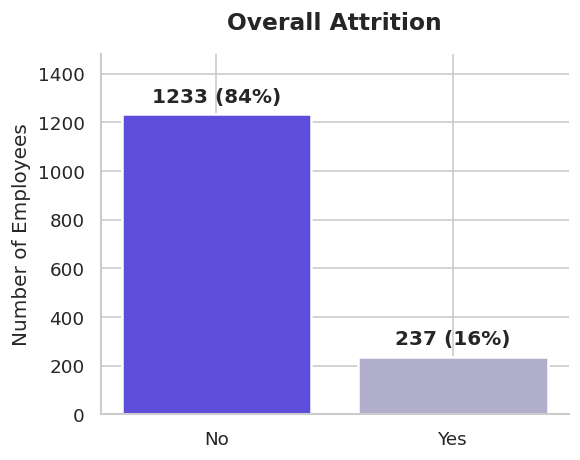

Attrition rate: 16.1%


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Attrition'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[ACCENT, NEUTRAL], edgecolor='white', linewidth=1.5)
ax.bar_label(bars, labels=[f"{v} ({v/len(df)*100:.0f}%)" for v in counts.values],
             padding=5, fontweight='bold')
ax.set_title('Overall Attrition', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Employees')
ax.set_ylim(0, max(counts.values) * 1.2)
plt.tight_layout()
plt.savefig('../reports/fig_01_overall_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Attrition rate: {df['AttritionFlag'].mean()*100:.1f}%")
 

### 3. Attrition by Departmen

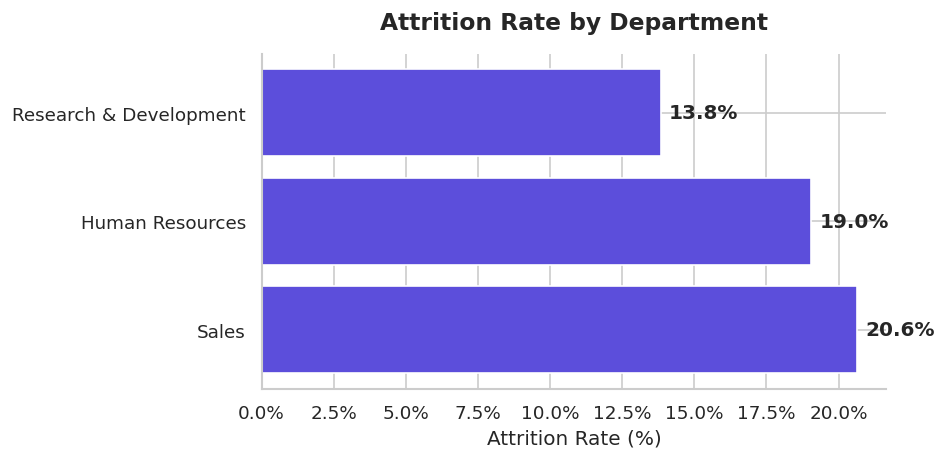

In [4]:
dept_agg = (df.groupby('Department')['AttritionFlag']
              .agg(['sum','count','mean'])
              .rename(columns={'sum':'Attrited','count':'Total','mean':'Rate'})
              .sort_values('Rate', ascending=False)
              .reset_index())
dept_agg['Rate_pct'] = dept_agg['Rate'] * 100
 
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept_agg['Department'], dept_agg['Rate_pct'],
               color=ACCENT, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in dept_agg['Rate_pct']],
             padding=5, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../reports/fig_02_dept_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Tenure vs Attrition (KEY FINDING: < 2 years = 3× risk)


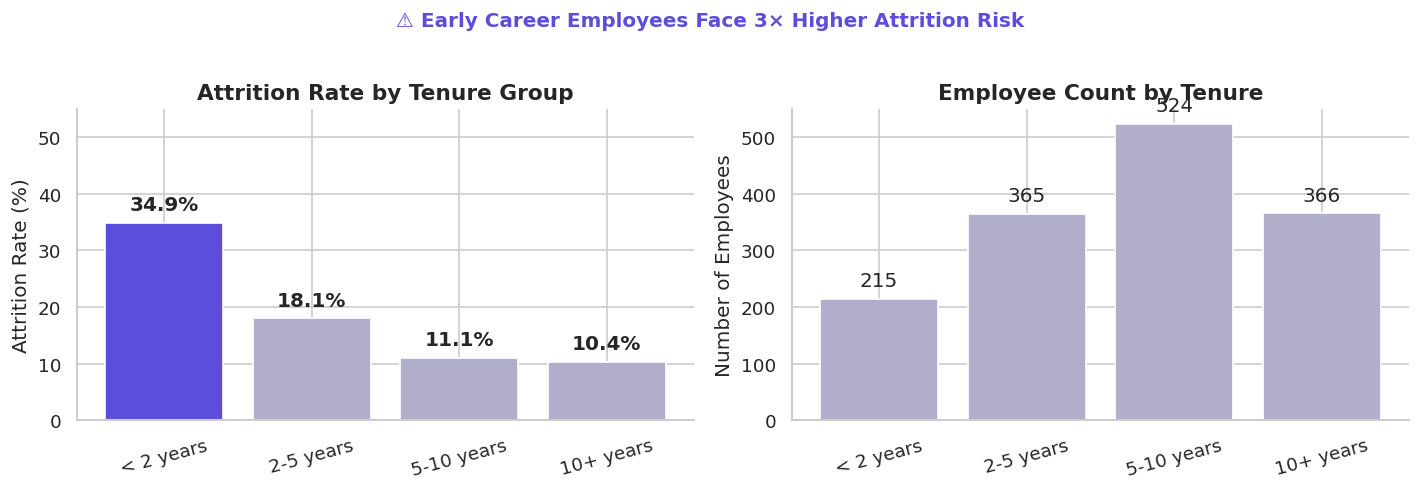

In [5]:

tenure_order = ['< 2 years', '2-5 years', '5-10 years', '10+ years']
tenure_agg = (df.groupby('TenureGroup')['AttritionFlag']
                .agg(['mean','count'])
                .rename(columns={'mean':'Rate','count':'Total'})
                .reindex(tenure_order)
                .reset_index())
tenure_agg['Rate_pct'] = tenure_agg['Rate'] * 100
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left: bar chart of attrition rate
colors = [ACCENT if g == '< 2 years' else NEUTRAL for g in tenure_agg['TenureGroup']]
bars = axes[0].bar(tenure_agg['TenureGroup'], tenure_agg['Rate_pct'],
                   color=colors, edgecolor='white')
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in tenure_agg['Rate_pct']],
                  padding=5, fontweight='bold')
axes[0].set_title('Attrition Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 55)
axes[0].tick_params(axis='x', rotation=15)
 
# Right: headcount
axes[1].bar(tenure_agg['TenureGroup'], tenure_agg['Total'],
            color=NEUTRAL, edgecolor='white')
axes[1].bar_label(axes[1].containers[0], padding=5)
axes[1].set_title('Employee Count by Tenure', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Employees')
axes[1].tick_params(axis='x', rotation=15)
 
plt.suptitle('⚠️ Early Career Employees Face 3× Higher Attrition Risk',
             fontsize=12, y=1.02, color=ACCENT, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_03_tenure_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Attrition by Salary Ban

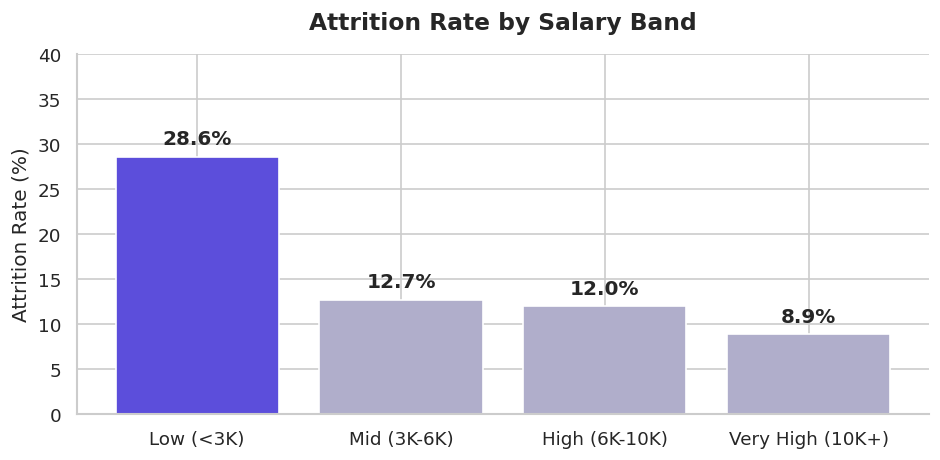

In [7]:
salary_order = ['Low (<3K)', 'Mid (3K-6K)', 'High (6K-10K)', 'Very High (10K+)']
sal_agg = (df.groupby('SalaryBand')['AttritionFlag']
             .agg(['mean','count'])
             .rename(columns={'mean':'Rate','count':'Total'})
             .reindex(salary_order)
             .reset_index())
sal_agg['Rate_pct'] = sal_agg['Rate'] * 100
 
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT if r > 20 else NEUTRAL for r in sal_agg['Rate_pct']]
bars = ax.bar(sal_agg['SalaryBand'], sal_agg['Rate_pct'],
              color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in sal_agg['Rate_pct']],
             padding=5, fontweight='bold')
ax.set_title('Attrition Rate by Salary Band', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 40)
plt.tight_layout()
plt.savefig('../reports/fig_04_salary_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
  

### 6. Job Satisfaction vs Attrition


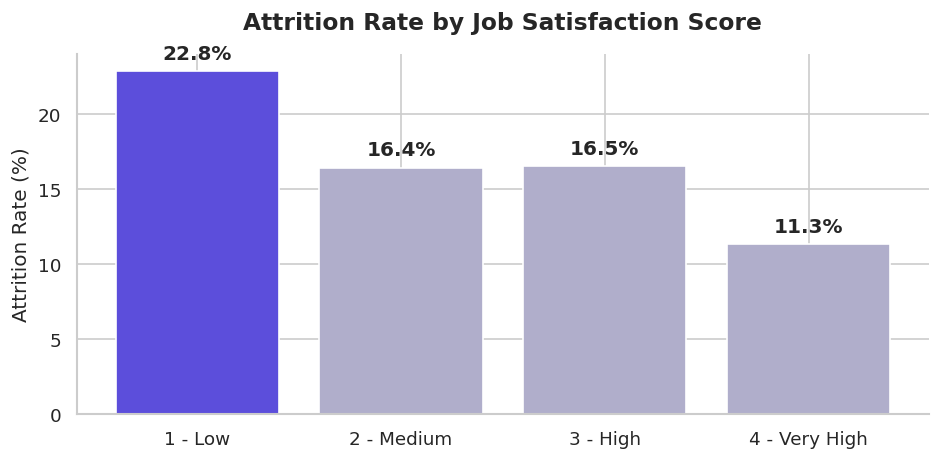

In [8]:
sat_agg = (df.groupby('JobSatisfaction')['AttritionFlag']
             .agg(['mean','count'])
             .rename(columns={'mean':'Rate','count':'Total'})
             .reset_index())
sat_agg['Rate_pct'] = sat_agg['Rate'] * 100
sat_labels = {1:'1 - Low', 2:'2 - Medium', 3:'3 - High', 4:'4 - Very High'}
sat_agg['Label'] = sat_agg['JobSatisfaction'].map(sat_labels)
 
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT if r > 20 else NEUTRAL for r in sat_agg['Rate_pct']]
bars = ax.bar(sat_agg['Label'], sat_agg['Rate_pct'],
              color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in sat_agg['Rate_pct']],
             padding=5, fontweight='bold')
ax.set_title('Attrition Rate by Job Satisfaction Score', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../reports/fig_05_satisfaction_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Overtime vs Attrition

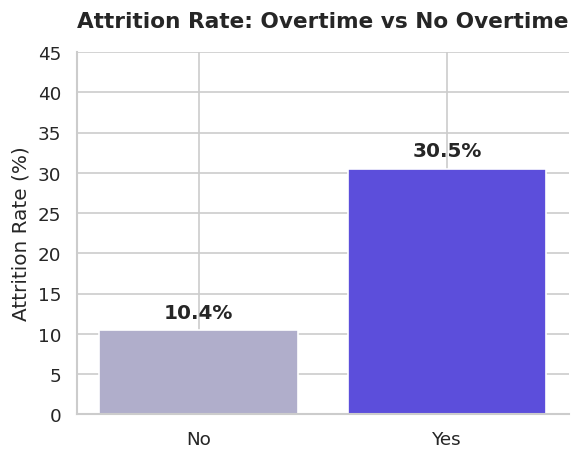

In [9]:
ot_agg = (df.groupby('OverTime')['AttritionFlag']
            .agg(['mean','count'])
            .rename(columns={'mean':'Rate','count':'Total'})
            .reset_index())
ot_agg['Rate_pct'] = ot_agg['Rate'] * 100
 
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(ot_agg['OverTime'], ot_agg['Rate_pct'],
              color=[NEUTRAL, ACCENT], edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in ot_agg['Rate_pct']],
             padding=5, fontweight='bold')
ax.set_title('Attrition Rate: Overtime vs No Overtime',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, 45)
plt.tight_layout()
plt.savefig('../reports/fig_06_overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. Job Role Heatmap

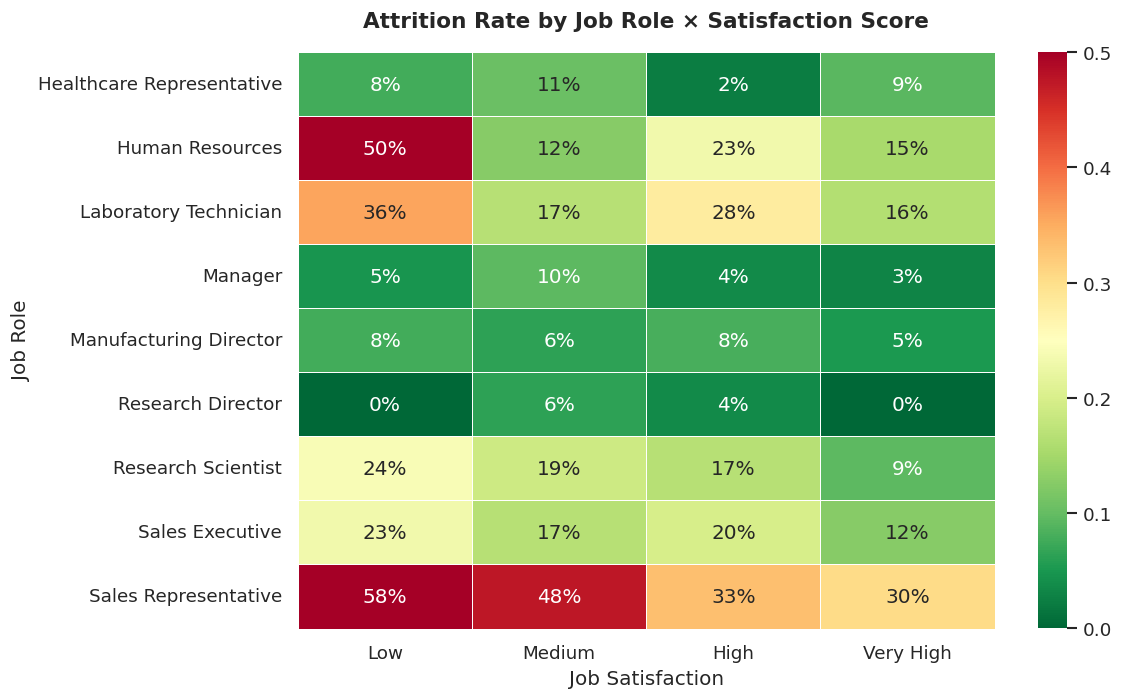

In [10]:
role_sat = df.groupby(['JobRole', 'JobSatisfactionLabel'])['AttritionFlag'].mean().unstack()
# Reorder satisfaction cols
order = ['Low', 'Medium', 'High', 'Very High']
role_sat = role_sat[[c for c in order if c in role_sat.columns]]
 
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(role_sat, annot=True, fmt='.0%', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=0.5)
ax.set_title('Attrition Rate by Job Role × Satisfaction Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Job Role')
ax.set_xlabel('Job Satisfaction')
plt.tight_layout()
plt.savefig('../reports/fig_07_role_satisfaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Monthly Income Distribution

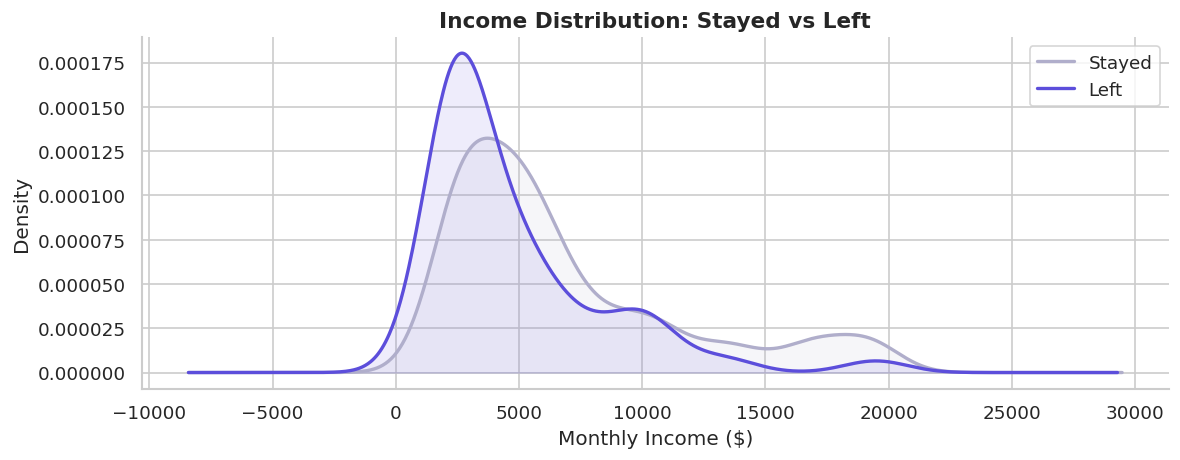


 All EDA visualizations saved to reports/


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
df[df['Attrition']=='No']['MonthlyIncome'].plot.kde(ax=ax, color=NEUTRAL, label='Stayed', linewidth=2)
df[df['Attrition']=='Yes']['MonthlyIncome'].plot.kde(ax=ax, color=ACCENT, label='Left', linewidth=2)
ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.1, color=NEUTRAL)
ax.fill_between(ax.lines[1].get_xdata(), ax.lines[1].get_ydata(), alpha=0.1, color=ACCENT)
ax.set_title('Income Distribution: Stayed vs Left', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Income ($)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_08_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\n All EDA visualizations saved to reports/")